In [1]:
import pandas as pd
import numpy as np

from sqlalchemy import create_engine

In [2]:
engine = create_engine(
    "mysql+pymysql://root:@localhost:3309/ecommerce_analytics1"
)
print("database connected")

database connected


In [3]:
query = """
SELECT
    c.customer_unique_id,

    MAX(o.order_purchase_timestamp) AS last_order,

    COUNT(DISTINCT o.order_id) AS frequency,

    ROUND(SUM(p.payment_value),2) AS monetary

FROM customers c

JOIN orders o
ON c.customer_id=o.customer_id

JOIN payments p
ON o.order_id=p.order_id

GROUP BY c.customer_unique_id
"""

rfm = pd.read_sql(query, engine)

rfm.head()

,customer_unique_id,last_order,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1,27.19
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,1,196.89


In [4]:
rfm['last_order'] = pd.to_datetime(
    rfm['last_order']
)

snapshot_date = (
    rfm['last_order'].max()
    + pd.Timedelta(days=1)
)

rfm['recency'] = (
    snapshot_date
    - rfm['last_order']
).dt.days

In [7]:
rfm['R'] = pd.qcut(
    rfm['recency'],
    q=5,
    labels=[5,4,3,2,1]
)

rfm['F'] = pd.qcut(
    rfm['frequency'].rank(method='first'),
    q=5,
    labels=[1,2,3,4,5]
)

rfm['M'] = pd.qcut(
    rfm['monetary'],
    q=5,
    labels=[1,2,3,4,5]
)

In [8]:
rfm['RFM_Score'] = (
    rfm['R'].astype(str)
    + rfm['F'].astype(str)
    + rfm['M'].astype(str)
)

In [9]:
def segment(row):

    if row['R'] >= 4 and row['F'] >= 4:
        return 'Champions'

    elif row['R'] >= 3 and row['F'] >= 3:
        return 'Loyal Customers'

    elif row['R'] >= 4:
        return 'Potential Loyalists'

    elif row['R'] <= 2:
        return 'At Risk'

    else:
        return 'Others'

rfm['Segment'] = rfm.apply(
    segment,
    axis=1
)

In [10]:
segment_summary = (
    rfm['Segment']
    .value_counts()
    .reset_index()
)

segment_summary

,Segment,count
0,At Risk,38429
1,Loyal Customers,19238
2,Champions,15453
3,Potential Loyalists,15448
4,Others,7527


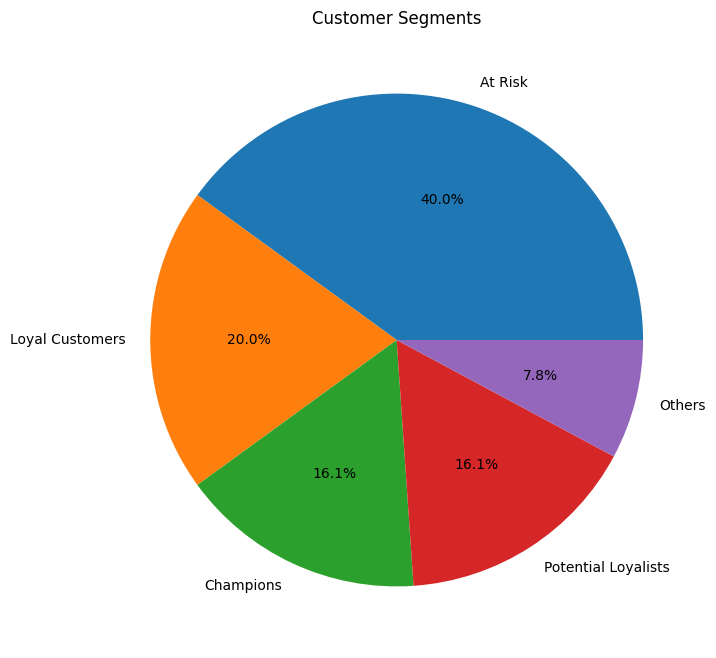

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

plt.pie(
    segment_summary['count'],
    labels=segment_summary['Segment'],
    autopct='%1.1f%%'
)

plt.title("Customer Segments")

plt.show()